# With Confidence Intervals

In [1]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 30/30 [00:00<00:00, 34.97it/s]


In [22]:
import numpy as np
from scipy.special import expit
from tqdm import tqdm

from utils_3 import leaderboard_dist
from utils_4 import (
    ij_from_pairwise,
    borda_ranking, borda_peeling_ranking,
    copeland_ranking, copeland_peeling_ranking,
    ml_argmax_ranking, ml_nonzero_ranking,
    expected_leaderboard_distortion,
)
from simulation_35 import sampled_ranking_dist

beta = 1.0
num_samples = 2000
num_rounds = 20
ml_sampling_rounds = 100

true_ranking = np.argsort(-population.avg_utilities)
candidates = np.arange(pw.M)

# empirical distribution over unordered pairs, from the pairwise dataset
empirical_pair_distribution = np.zeros((pw.M, pw.M))
for i in range(len(pw.winners)):
    first = max(pw.winners[i], pw.losers[i])
    second = min(pw.winners[i], pw.losers[i])
    empirical_pair_distribution[first, second] += 1.0
empirical_pair_distribution /= empirical_pair_distribution.sum()

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling',
           'ml_argmax', 'ml_nonzero', 'ml_sampling']
distortions = {m: [] for m in methods}

for _ in tqdm(range(num_rounds)):
    # sample 200 pairwise comparisons: pairs from the empirical pair distribution,
    # winners from the population utilities (Bradley-Terry with the given beta)
    flattened = empirical_pair_distribution.ravel()
    indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
    coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
    model_As = coords[..., 0]
    model_Bs = coords[..., 1]

    u_diff = population.population_utilities[:, model_As] - population.population_utilities[:, model_Bs]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

    for name, fn in [
        ('borda', borda_ranking),
        ('borda_peeling', borda_peeling_ranking),
        ('copeland', copeland_ranking),
        ('copeland_peeling', copeland_peeling_ranking),
        ('ml_argmax', ml_argmax_ranking),
        ('ml_nonzero', ml_nonzero_ranking),
    ]:
        ranking = fn(ij_wins)
        dist, _ = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
        distortions[name].append(dist)

    ranking_dist_sampled = sampled_ranking_dist(candidates, ij_wins, rounds=ml_sampling_rounds)
    dist = expected_leaderboard_distortion(ranking_dist_sampled, true_ranking, population.avg_utilities)
    distortions['ml_sampling'].append(dist)

distortions = {k: np.array(v) for k, v in distortions.items()}
distortions

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [01:14<00:00,  3.73s/it]


{'borda': array([1.18935551, 1.16500878, 1.11951997, 1.22796671, 1.33154842,
        1.30346244, 1.29100407, 1.34996327, 1.28936412, 1.25972688,
        1.21079729, 1.30544361, 1.59873196, 1.30605647, 1.27563755,
        1.54776979, 1.62813075, 1.27491227, 1.90610914, 1.72649637]),
 'borda_peeling': array([1.18942014, 1.19151544, 1.19875064, 1.28527268, 1.27112977,
        1.30346244, 1.35516205, 1.34996327, 1.51991023, 1.2213159 ,
        1.32879323, 1.33612883, 1.59873196, 1.35687685, 1.31782974,
        1.54776979, 1.35081308, 1.3207945 , 1.79919501, 1.72649637]),
 'copeland': array([1.22340149, 1.20496247, 1.12493746, 1.31990439, 1.34859342,
        1.943626  , 1.30593176, 1.37276412, 1.98769271, 1.29798044,
        1.18154792, 1.29301662, 1.59873196, 1.22743993, 1.27563755,
        1.37763906, 1.63622888, 1.2872409 , 1.99108463, 1.74407055]),
 'copeland_peeling': array([1.22340149, 1.19761313, 1.18990458, 1.34582962, 1.30961173,
        1.943626  , 1.34577793, 1.38939051, 1.987692

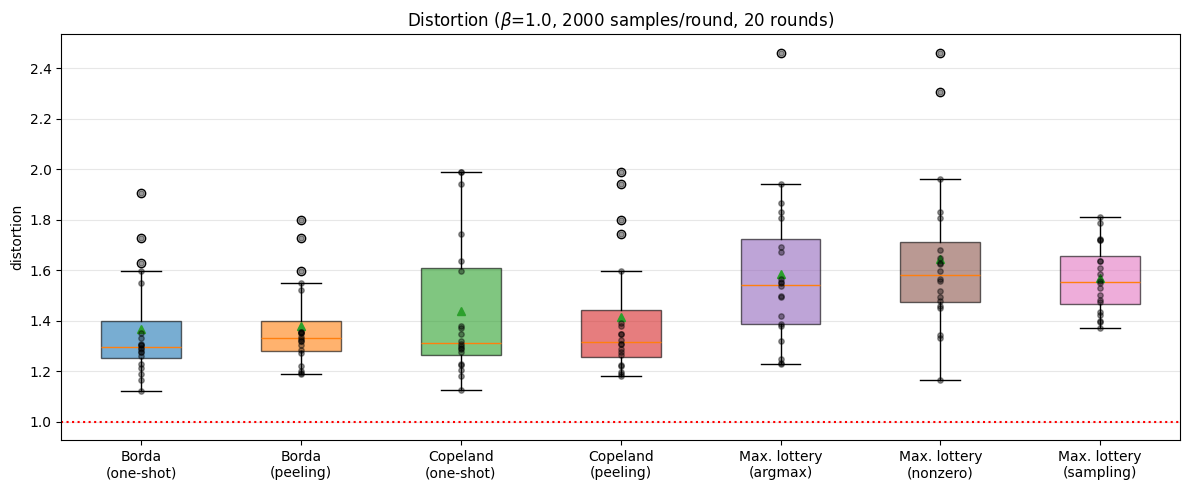

In [24]:
import matplotlib.pyplot as plt

labels = {
    'borda':            'Borda\n(one-shot)',
    'borda_peeling':    'Borda\n(peeling)',
    'copeland':         'Copeland\n(one-shot)',
    'copeland_peeling': 'Copeland\n(peeling)',
    'ml_argmax':        'Max. lottery\n(argmax)',
    'ml_nonzero':       'Max. lottery\n(nonzero)',
    'ml_sampling':      'Max. lottery\n(sampling)',
}
colors = [f'C{i}' for i in range(len(methods))]

fig, ax = plt.subplots(figsize=(12, 5))
data = [distortions[m] for m in methods]
bp = ax.boxplot(data, tick_labels=[labels[m] for m in methods], patch_artist=True,
                 showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for xi, m in enumerate(methods, start=1):
    ax.scatter(np.full(num_rounds, xi), distortions[m], color='black', alpha=0.4, zorder=3, s=15)

ax.axhline(1.0, color='red', linestyle=':', linewidth=1.5, zorder=2)

ax.set_ylabel('distortion')
ax.set_title(f'Distortion ($\\beta$={beta}, {num_samples} samples/round, {num_rounds} rounds)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
import numpy as np
from scipy.special import expit
from tqdm import tqdm

from utils_3 import leaderboard_dist
from utils_4 import (
    ij_from_pairwise,
    borda_ranking, borda_peeling_ranking,
    copeland_ranking, copeland_peeling_ranking,
    ml_argmax_ranking, ml_nonzero_ranking,
    expected_leaderboard_distortion,
)
from simulation_35 import sampled_ranking_dist

beta = 1.0
num_samples = 4000
num_rounds = 20
ml_sampling_rounds = 100

true_ranking = np.argsort(-population.avg_utilities)
candidates = np.arange(pw.M)

# empirical distribution over unordered pairs, from the pairwise dataset
empirical_pair_distribution = np.zeros((pw.M, pw.M))
for i in range(len(pw.winners)):
    first = max(pw.winners[i], pw.losers[i])
    second = min(pw.winners[i], pw.losers[i])
    empirical_pair_distribution[first, second] += 1.0
empirical_pair_distribution /= empirical_pair_distribution.sum()

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling',
           'ml_argmax', 'ml_nonzero', 'ml_sampling']
distortions = {m: [] for m in methods}

for _ in tqdm(range(num_rounds)):
    # sample 200 pairwise comparisons: pairs from the empirical pair distribution,
    # winners from the population utilities (Bradley-Terry with the given beta)
    flattened = empirical_pair_distribution.ravel()
    indices = np.random.choice(len(flattened), size=num_samples, p=flattened)
    coords = np.array(np.unravel_index(indices, empirical_pair_distribution.shape)).T
    model_As = coords[..., 0]
    model_Bs = coords[..., 1]

    u_diff = population.population_utilities[:, model_As] - population.population_utilities[:, model_Bs]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

    for name, fn in [
        ('borda', borda_ranking),
        ('borda_peeling', borda_peeling_ranking),
        ('copeland', copeland_ranking),
        ('copeland_peeling', copeland_peeling_ranking),
        ('ml_argmax', ml_argmax_ranking),
        ('ml_nonzero', ml_nonzero_ranking),
    ]:
        ranking = fn(ij_wins)
        dist, _ = leaderboard_dist(ranking, true_ranking, population.avg_utilities)
        distortions[name].append(dist)

    ranking_dist_sampled = sampled_ranking_dist(candidates, ij_wins, rounds=ml_sampling_rounds)
    dist = expected_leaderboard_distortion(ranking_dist_sampled, true_ranking, population.avg_utilities)
    distortions['ml_sampling'].append(dist)

distortions = {k: np.array(v) for k, v in distortions.items()}
distortions

100%|██████████| 20/20 [01:13<00:00,  3.69s/it]


{'borda': array([1.56637182, 1.18935551, 1.16500878, 1.56637182, 1.17696166,
        1.2836058 , 1.17640221, 1.26564745, 1.17696166, 1.285708  ,
        1.1124649 , 1.49249819, 1.35409992, 1.18935551, 1.14937365,
        1.1906075 , 1.6211446 , 1.26721508, 1.28936412, 1.38094291]),
 'borda_peeling': array([1.56637182, 1.23575362, 1.1797427 , 1.56637182, 1.17696166,
        1.38852328, 1.19205451, 1.41010187, 1.17696166, 1.36003916,
        1.14937365, 1.49249819, 1.27474328, 1.18935551, 1.17227771,
        1.26612413, 1.6211446 , 1.26721508, 1.28936412, 1.38094291]),
 'copeland': array([1.79919501, 1.43406284, 1.08395828, 1.56637182, 1.10894253,
        2.02952467, 1.29020261, 1.22683626, 1.25972688, 1.27054355,
        1.22340149, 1.1243545 , 1.24097354, 1.28936412, 1.27943978,
        1.20169479, 1.6211446 , 1.28936412, 1.40529305, 1.251903  ]),
 'copeland_peeling': array([1.79919501, 1.52533697, 1.11548279, 1.56637182, 1.12381517,
        2.02952467, 1.30754365, 1.16500878, 1.165008

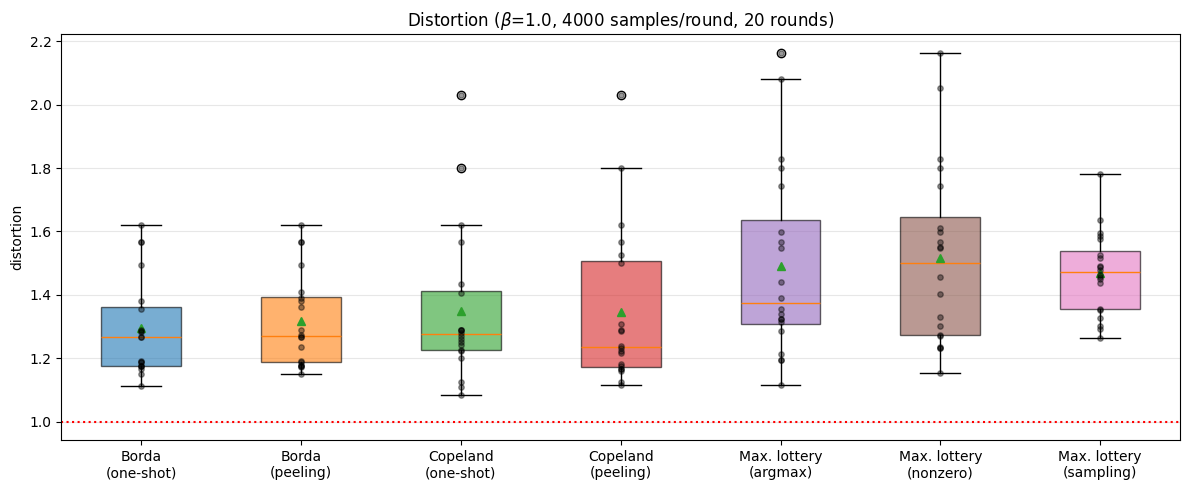

In [26]:
import matplotlib.pyplot as plt

labels = {
    'borda':            'Borda\n(one-shot)',
    'borda_peeling':    'Borda\n(peeling)',
    'copeland':         'Copeland\n(one-shot)',
    'copeland_peeling': 'Copeland\n(peeling)',
    'ml_argmax':        'Max. lottery\n(argmax)',
    'ml_nonzero':       'Max. lottery\n(nonzero)',
    'ml_sampling':      'Max. lottery\n(sampling)',
}
colors = [f'C{i}' for i in range(len(methods))]

fig, ax = plt.subplots(figsize=(12, 5))
data = [distortions[m] for m in methods]
bp = ax.boxplot(data, tick_labels=[labels[m] for m in methods], patch_artist=True,
                 showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for xi, m in enumerate(methods, start=1):
    ax.scatter(np.full(num_rounds, xi), distortions[m], color='black', alpha=0.4, zorder=3, s=15)

ax.axhline(1.0, color='red', linestyle=':', linewidth=1.5, zorder=2)

ax.set_ylabel('distortion')
ax.set_title(f'Distortion ($\\beta$={beta}, {num_samples} samples/round, {num_rounds} rounds)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


TODO: focus on one-shot Borda -> does the most optimistic interpretation explain?

Does the true ranking exist in the overlap of possible Borda scores.

M candidates, M intervals - distortion of most optimistic ranking.

In [28]:
from datasets import load_dataset

# Load all historical text style control data
# ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="full")

# Load the current text style control leaderboard
ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="latest")

# Filter to overall category
# ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="latest",
#     filters=[("category", "==", "overall")]
# )

# Track a specific model's rating over time
# ds = load_dataset("lmarena-ai/leaderboard-dataset", "text_style_control", split="full",
#     filters=[("category", "==", "overall"), ("model_name", "==", "gpt-4o-2024-05-13")],
#     columns=["model_name", "rating", "rank", "leaderboard_publish_date"]
# )

# Load raw (non-style-controlled) text ratings
# ds = load_dataset("lmarena-ai/leaderboard-dataset", "text", split="full")


In [31]:
set(ds['category'])

{'chinese',
 'coding',
 'creative_writing',
 'english',
 'exclude_ties',
 'expert',
 'french',
 'german',
 'hard_prompts',
 'hard_prompts_english',
 'industry_business_and_management_and_financial_operations',
 'industry_entertainment_and_sports_and_media',
 'industry_legal_and_government',
 'industry_life_and_physical_and_social_science',
 'industry_mathematical',
 'industry_medicine_and_healthcare',
 'industry_software_and_it_services',
 'industry_writing_and_literature_and_language',
 'instruction_following',
 'japanese',
 'korean',
 'longer_query',
 'math',
 'multi_turn',
 'overall',
 'russian',
 'spanish'}

In [ ]:
n_resamples = 1000
ci = 0.95

def sample_ij_wins():
    mask = np.random.rand(num_samples) < p
    w_arr = np.where(mask, model_As, model_Bs)
    l_arr = np.where(mask, model_Bs, model_As)
    return ij_from_pairwise(w_arr, l_arr, pw.M)

scores = np.array([
    borda_ranking(sample_ij_wins(), with_scores=True)[1]
    for _ in tqdm(range(n_resamples))
])

alpha = 1.0 - ci
ci_lo, ci_hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)], axis=0)
score_min, score_max = scores.min(axis=0), scores.max(axis=0)

In [ ]:
def true_ranking_is_possible(true_ranking, lo, hi):
    ceiling = hi[true_ranking[0]]
    for c in true_ranking[1:]:
        if lo[c] >= ceiling:
            return False
        ceiling = min(hi[c], ceiling)
    return True

print('possible with min/max range:', true_ranking_is_possible(true_ranking, score_min, score_max))
print(f'possible with {int(ci*100)}% CI range:', true_ranking_is_possible(true_ranking, ci_lo, ci_hi))